# Evaluating Explanations with OpenXAI

When we use a post-hoc explainer (LIME, SHAP, Integrated Gradients, …) we get a feature-importance vector back. But how do we know if that explanation is any *good*? OpenXAI gives us a toolbox of evaluation metrics to answer that.

In this notebook we will:
1. Load the **Adult** income dataset and a pre-trained **logistic regression** model.
2. Generate explanations with four different methods: **LIME, Integrated Gradients, SHAP, and Gradient**.
3. Evaluate those explanations with three families of metrics:
   - **Ground-truth faithfulness** (FA, RA, RC): does the explanation agree with the true model coefficients?
   - **Predictive faithfulness** (PGI, PGU): when we perturb the "important" features, does the prediction change?
   - **Stability** (RIS) :does the explanation change a lot for nearly-identical inputs?
4. Visualize and compare methods side-by-side.

OpenXAI isn't on PyPI, so we install it directly from the GitHub repo. We also get the default `experiment_config.json` that ships with the library.

In [ ]:
%pip install -q git+https://github.com/AI4LIFE-GROUP/OpenXAI.git 'pandas<2.3'
!wget -q -nc https://raw.githubusercontent.com/AI4LIFE-GROUP/OpenXAI/main/experiment_config.json

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 27.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from openxai.experiment_utils import load_config, fill_param_dict
from openxai.explainers.perturbation_methods import get_perturb_method
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders, ReturnTrainTestX
from openxai.explainer import Explainer
from openxai.evaluator import Evaluator, ground_truth_metrics, prediction_metrics, stability_metrics

np.random.seed(0)
torch.manual_seed(0)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load the dataset

We're using the **Adult** dataset: predict whether a person earns >$50K/year from demographic features. The features (age, education, sex, race, …) are human-interpretable, which makes feature-attribution explanations easy to sanity-check visually.

In [ ]:
DATA_NAME = 'adult'
MODEL_NAME = 'lr'  # logistic regression — gives us ground-truth explanations (the LR coefficients)
N_TEST = 50        # keep small so evaluation is fast in Colab

trainloader, testloader = ReturnLoaders(data_name=DATA_NAME, download=True, batch_size=N_TEST)
inputs, labels = next(iter(testloader))
labels = labels.type(torch.int64)

X_train, X_test, feature_metadata = ReturnTrainTestX(
    DATA_NAME, float_tensor=True, return_feature_metadata=True
)
feature_names = trainloader.dataset.feature_names  # human-readable names

# Cap the test set used for the slower metrics (stability / PGI / PGU)
X_test_small = X_test[:N_TEST]

print(f'Training set:   {tuple(X_train.shape)}')
print(f'Test set:       {tuple(X_test.shape)}')
print(f'Evaluating on:  {N_TEST} test instances')
print(f'# features:     {X_train.shape[1]}')
print(f'Feature names:  {feature_names}')
print(f'Feature types:  {sorted(set(feature_metadata))}  (c=continuous, d=discrete)')

Training set:   (36177, 13)
Test set:       (9045, 13)
Evaluating on:  50 test instances
# features:     13
Feature names:  ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'sex_Male', 'workclass_Private', 'marital-status_Non-Married', 'occupation_Other', 'relationship_Non-Husband', 'race_White', 'native-country_US']
Feature types:  ['c', 'd']  (c=continuous, d=discrete)


In [ ]:
# Peek at the data
df_preview = pd.DataFrame(inputs.numpy()[:5], columns=feature_names)
df_preview['label'] = labels.numpy()[:5]
df_preview

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,sex_Male,workclass_Private,marital-status_Non-Married,occupation_Other,relationship_Non-Husband,race_White,native-country_US,label
0,0.136986,0.151121,0.533333,0.0,0.0,0.193878,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0
1,0.273973,0.070657,0.733333,0.0,0.0,0.295918,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0
2,0.452055,0.197689,0.866667,0.0,0.0,0.397959,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1
3,0.109589,0.144896,0.533333,0.0,0.0,0.397959,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0
4,0.178082,0.195471,0.466667,0.0,0.0,0.397959,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0


## 2. Load a pre-trained model

OpenXAI also contains models already trained on each benchmark dataset. We will use a **logistic regression**.

In [ ]:
model = LoadModel(data_name=DATA_NAME, ml_model=MODEL_NAME, pretrained=True)
model.eval()

with torch.no_grad():
    test_preds_all = model(X_test.float()).argmax(1).numpy()
    preds = model(inputs.float()).argmax(1)

y_test = np.array(testloader.dataset.targets)
acc = (test_preds_all == y_test).mean()
print(f'Test accuracy: {acc:.3f}')
print(f'Prediction distribution (sample): {np.bincount(preds.numpy())}')

Test accuracy: 0.833
Prediction distribution (sample): [41  9]


## 3. Generate explanations with four methods

Each explainer takes a model and produces, per input, a vector of feature attributions (positive = pushed prediction toward class 1, negative = away). We'll compare LIME, SHAP, Integrated Gradients and raw gradient.

In [ ]:
config = load_config('experiment_config.json')

def compute_explanations(method_name):
    params = fill_param_dict(method_name, config['explainers'][method_name].copy(), X_train)
    exp = Explainer(method_name, model, params)
    return exp.get_explanations(inputs.float(), preds).detach().numpy(), exp

explanations = {}
explainer_objs = {}
for m in ['lime', 'shap', 'ig', 'grad']:
    print(f'Computing {m.upper()} explanations ...')
    explanations[m], explainer_objs[m] = compute_explanations(m)

print('\nExplanation shape (n_instances, n_features):', explanations['lime'].shape)

Computing LIME explanations ...
Computing SHAP explanations ...
Computing IG explanations ...
Computing GRAD explanations ...

Explanation shape (n_instances, n_features): (50, 13)


### 3a. Visualizing one instance to check if the methods agree

Let's pick a single test point and look at the top attributions from each method.

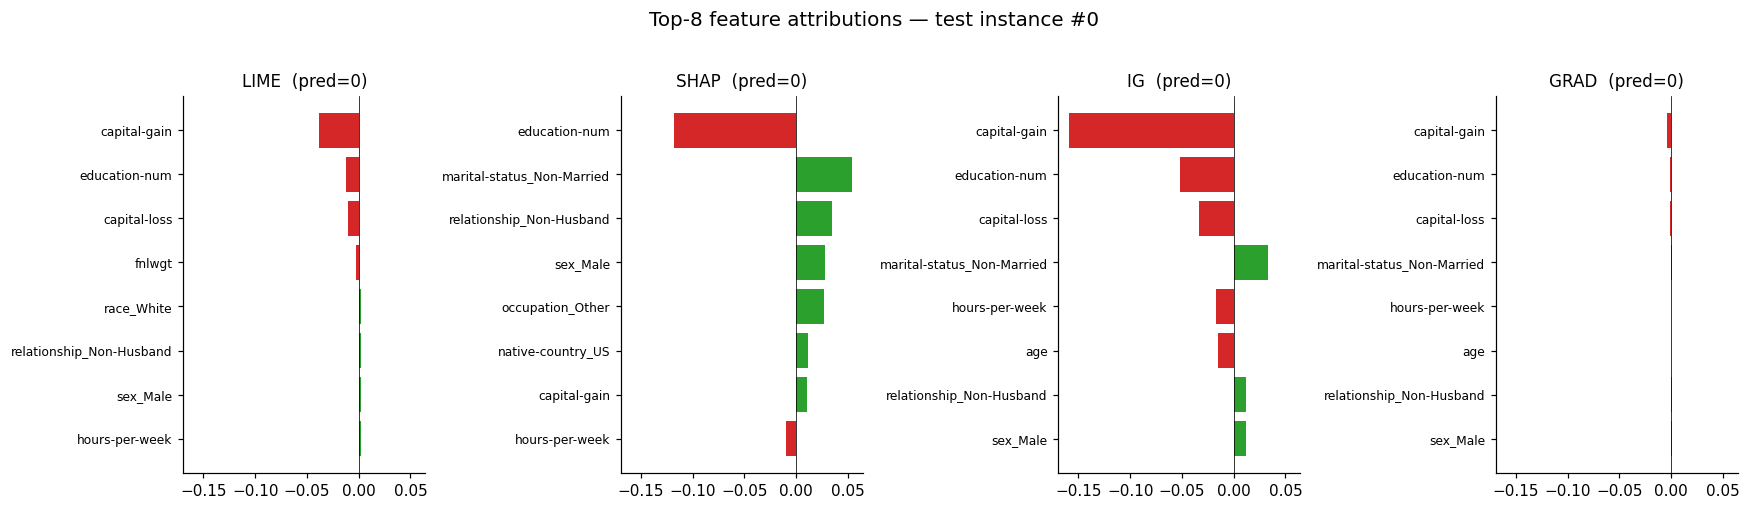

In [ ]:
idx = 0  # which test instance to inspect
top_k = 8

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharex=True)
for ax, (m, exps) in zip(axes, explanations.items()):
    e = exps[idx]
    order = np.argsort(np.abs(e))[::-1][:top_k][::-1]
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in e[order]]
    ax.barh(range(top_k), e[order], color=colors)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'{m.upper()}  (pred={preds[idx].item()})', fontsize=11)

fig.suptitle(f'Top-{top_k} feature attributions — test instance #{idx}', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 3b. Heatmap across many instances

Are the methods consistently highlighting the same features across the test set? Red = pushes toward class 1, blue = away.

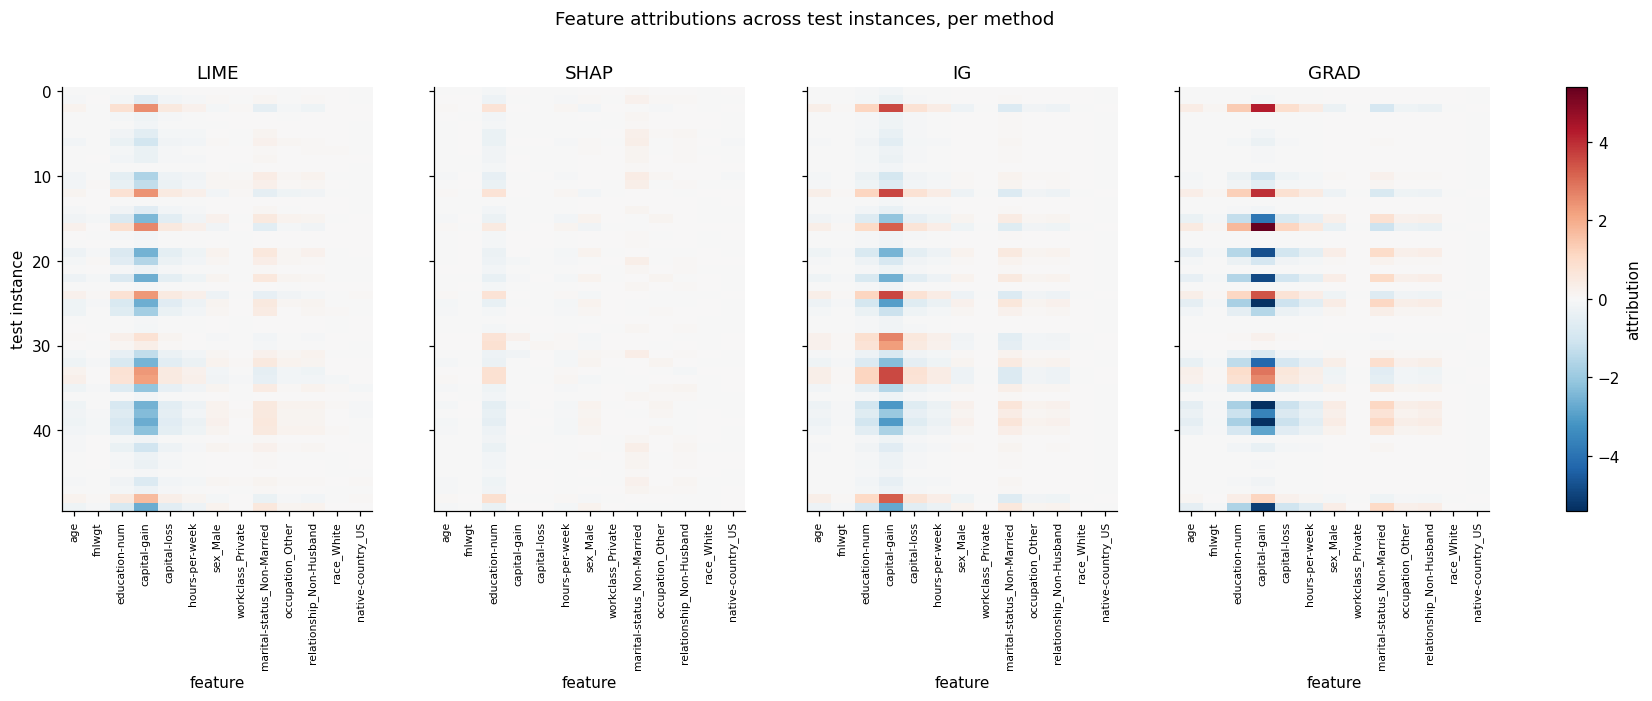

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
vmax = max(np.abs(e).max() for e in explanations.values())
for ax, (m, e) in zip(axes, explanations.items()):
    im = ax.imshow(e, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(m.upper())
    ax.set_xticks(range(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
    ax.set_xlabel('feature')
axes[0].set_ylabel('test instance')
fig.colorbar(im, ax=axes, fraction=0.02, label='attribution')
plt.suptitle('Feature attributions across test instances, per method', y=1.02)
plt.show()

## 4. Ground-truth faithfulness metrics

Because our model is a logistic regression, we know the "true" feature importances: they are the learned coefficients. We can directly compare each explainer's output to that ground truth.

| Metric | What it measures | Range | Rule of thumb |
| --- | --- | --- | --- |
| **FA** — Feature Agreement | Fraction of top-k features that match the ground truth | [0, 1] | > 0.7 strong · 0.4–0.7 partial · < 0.3 poor |
| **RA** — Rank Agreement | Top-k features match *and* are in the same order | [0, 1] | Always ≤ FA. > 0.6 is very strong |
| **RC** — Rank Correlation | Spearman ρ between explanation ranks and GT ranks | [-1, 1] | > 0.7 strong · ~0 random · < 0 wrong ordering |

Gradient-based methods (Grad, IG) look suspiciously perfect here. For an LR model, `∂output/∂input` literally *is* the coefficient vector — so the gradient explanation equals the ground truth by construction. LIME builds a local linear surrogate, so it should also score well. SHAP and perturbation-based methods may underperform on this dataset even though they're solid methods in general, as they optimize for something slightly different (Shapley values ≠ model coefficients when features are correlated).


In [ ]:
def eval_ground_truth(metric, exps):
    params = config['evaluators']['ground_truth_metrics'].copy()
    params['explanations'] = exps
    if metric in ['FA', 'RA', 'SA', 'SRA']:
        params['predictions'] = preds
    elif metric in ['PRA', 'RC']:
        params.pop('k', None)
        params.pop('AUC', None)
    _, mean_score = Evaluator(model, metric).evaluate(**params)
    return float(mean_score)

gt_results = {m: {} for m in explanations}
for m, exps in explanations.items():
    for metric in ['FA', 'RA', 'RC']:
        gt_results[m][metric] = eval_ground_truth(metric, exps)

pd.DataFrame(gt_results).T.style.format('{:.3f}').background_gradient(cmap='Greens', axis=0)

,FA,RA,RC
lime,0.909,0.843,0.876
shap,0.360,0.026,0.317
ig,1.000,1.000,1.000
grad,1.000,1.000,1.000


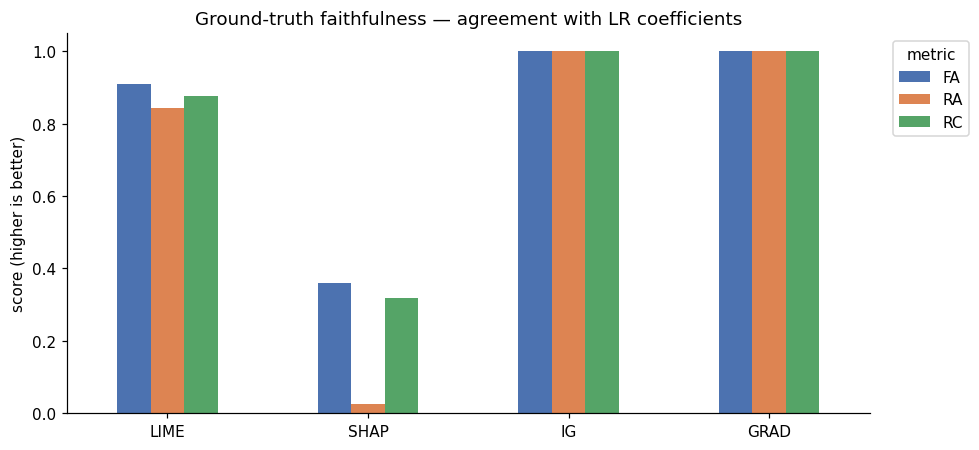

In [ ]:
df_gt = pd.DataFrame(gt_results).T
ax = df_gt.plot(kind='bar', figsize=(9, 4.2), color=['#4C72B0', '#DD8452', '#55A467'])
ax.set_ylabel('score (higher is better)')
ax.set_title('Ground-truth faithfulness — agreement with LR coefficients')
ax.legend(title='metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels([m.upper() for m in df_gt.index], rotation=0)
plt.tight_layout()
plt.show()

### Comparing to the OpenXAI leaderboard

The [OpenXAI leaderboard](https://open-xai.github.io/leaderboard) reports these reference values on Adult + LR:

| Method | FA | RA | RC |
| --- | --- | --- | --- |
| Grad  | 0.92 | 0.92 | 1.00 |
| IG    | 0.92 | 0.92 | 1.00 |
| SHAP  | 0.60 | 0.11 | 0.38 |
| LIME  | 0.87 | 0.70 | 0.92 |

**What to read from this:**
- **Grad/IG hitting RC = 1.0** is not the methods being amazing, it's a consequence of the model being linear. On a neural net this pattern disappears.
- **LIME lands in the 0.7–0.9 band** — very good, because its local linear surrogate naturally aligns with a globally linear model.
- **SHAP's low RA (~0.1)** is surprising until you realize: Shapley values redistribute contribution among correlated features, so the *top-k set* often differs from the raw LR coefficients even when the two explanations are "equivalent" in a game-theoretic sense.

Our notebook run may differ slightly because we only use 50 test instances vs the leaderboard's full test set.


## 5. Predictive faithfulness: PGI & PGU

These metrics don't need ground truth as they check whether the explanation is self-consistent with the *model's behavior*:

- **PGI** (Prediction Gap on *Important* features) :perturb features the explainer flagged as important. The prediction *should* change a lot. **Higher is better.**
- **PGU** (Prediction Gap on *Unimportant* features): perturb features the explainer flagged as unimportant. The prediction *should* stay put. **Lower is better.**

| Metric | Range | Interpretation |
| --- | --- | --- |
| **PGI ↑** | [0, ~1] (bounded by max change in predicted probability) | > 0.3 strong · 0.1–0.3 moderate · < 0.05 the "important" features weren't important |
| **PGU ↓** | [0, ~1] | < 0.1 strong · 0.1–0.2 acceptable · > 0.3 the "unimportant" features actually matter |

A good explanation has **high PGI *and* low PGU** — top-left corner of the scatter below.

On a logistic regression model you'll see **IG and Grad produce identical PGI/PGU values**. That's not a bug. For a linear model, Integrated Gradients reduces to (gradient × Δinput), so its feature *ranking* is the same as raw Gradient. The two methods diverge only on non-linear models, at home try `MODEL_NAME = 'ann'` to see the split.


In [ ]:
def eval_prediction(metric, exps):
    params = config['evaluators']['prediction_metrics'].copy()
    params['inputs'] = X_test_small
    params['explanations'] = exps[:N_TEST]
    params['feature_metadata'] = feature_metadata
    params['perturb_method'] = get_perturb_method(params['std'], DATA_NAME)
    params.pop('std')
    _, mean_score = Evaluator(model, metric).evaluate(**params)
    return float(mean_score)

# Use test-set explanations (match X_test_small). Recompute for X_test_small predictions.
preds_xtest = model(X_test_small.float()).argmax(1)
test_explanations = {}
for m in ['lime', 'shap', 'ig', 'grad']:
    params = fill_param_dict(m, config['explainers'][m].copy(), X_train)
    test_explanations[m] = Explainer(m, model, params).get_explanations(
        X_test_small, preds_xtest
    ).detach().numpy()

pred_results = {m: {} for m in test_explanations}
for m, exps in test_explanations.items():
    for metric in ['PGI', 'PGU']:
        print(f'  {m.upper()}  {metric} ...')
        pred_results[m][metric] = eval_prediction(metric, exps)

df_pred = pd.DataFrame(pred_results).T
df_pred

  LIME  PGI ...
  LIME  PGU ...
  SHAP  PGI ...
  SHAP  PGU ...
  IG  PGI ...
  IG  PGU ...
  GRAD  PGI ...
  GRAD  PGU ...


,PGI,PGU
lime,0.125594,0.061676
shap,0.057882,0.127819
ig,0.123234,0.063096
grad,0.123234,0.063096


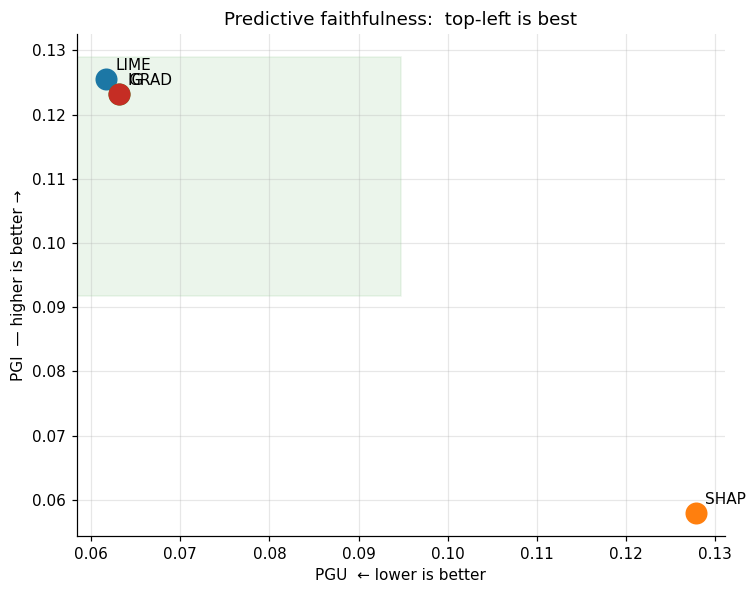

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for m in df_pred.index:
    ax.scatter(df_pred.loc[m, 'PGU'], df_pred.loc[m, 'PGI'], s=180, label=m.upper())
    ax.annotate(m.upper(), (df_pred.loc[m, 'PGU'], df_pred.loc[m, 'PGI']),
                xytext=(6, 6), textcoords='offset points', fontsize=10)
ax.set_xlabel('PGU  ← lower is better')
ax.set_ylabel('PGI  — higher is better →')
ax.set_title('Predictive faithfulness:  top-left is best')
ax.grid(alpha=0.3)
# Shade the "good" quadrant
xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.axhspan(np.mean(ylim), ylim[1], xmin=0, xmax=0.5, alpha=0.08, color='green')
plt.tight_layout()
plt.show()

## 6. Stability: RIS

**Relative Input Stability (RIS)** asks: if I perturb the input slightly, does the explanation change a lot? A reliable explainer should be *stable*: small input changes → small explanation changes.

| Metric | Range | Interpretation |
| --- | --- | --- |
| **log(RIS) ↓** | (-∞, +∞) | < 0 excellent (explanation changes less than the input) · 0–4 moderate · 4–7 unstable · > 7 very unstable |

RIS is a *ratio* (‖Δ explanation‖ / ‖Δ input‖), and perturbation-based methods use internal randomness, so the values span many orders of magnitude. We report **log(RIS)** to make the comparison readable.


In [ ]:
def eval_stability(method_name, metric='RIS', n_inputs=20, n_samples=50, n_perturbations=30):
    """Reduced sample counts so this runs in a reasonable time on Colab CPU."""
    exp_params = fill_param_dict(method_name, config['explainers'][method_name].copy(), X_train)
    explainer = Explainer(method_name, model, exp_params)

    params = config['evaluators']['stability_metrics'].copy()
    params['inputs'] = X_test_small[:n_inputs]
    params['explainer'] = explainer
    params['feature_metadata'] = feature_metadata
    params['perturb_method'] = get_perturb_method(params['std'], DATA_NAME)
    params['n_samples'] = n_samples
    params['n_perturbations'] = n_perturbations
    params.pop('std')

    _, mean_score = Evaluator(model, metric).evaluate(**params)
    return float(mean_score)

ris_results = {}
for m in ['lime', 'shap', 'ig', 'grad']:
    print(f'  RIS for {m.upper()} ...')
    ris_results[m] = eval_stability(m)

ris_df = pd.Series(ris_results, name='RIS').to_frame()
ris_df['log(RIS)'] = np.log(ris_df['RIS'])
ris_df

  RIS for LIME ...
  RIS for SHAP ...
  RIS for IG ...
  RIS for GRAD ...


,RIS,log(RIS)
lime,110284.710938,11.610821
shap,99084.046875,11.503724
ig,12.253386,2.505802
grad,49.115944,3.894184


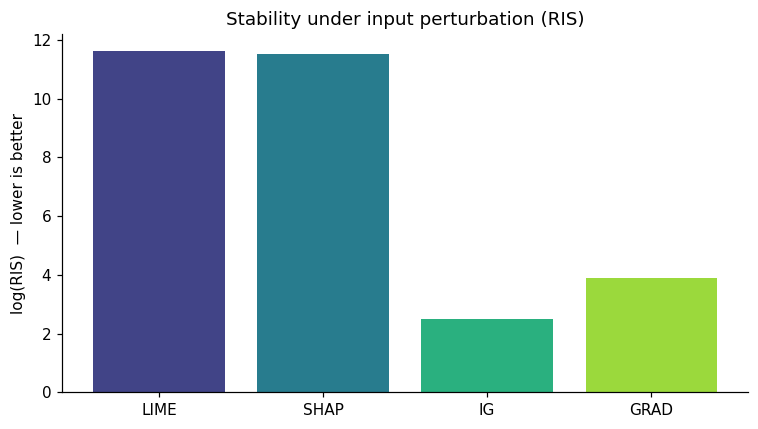

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
methods = list(ris_results.keys())
vals = [np.log(ris_results[m]) for m in methods]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(methods)))
ax.bar([m.upper() for m in methods], vals, color=colors)
ax.set_ylabel('log(RIS)  — lower is better')
ax.set_title('Stability under input perturbation (RIS)')
ax.axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

## 7. Fairness across subgroups

A method's *average* faithfulness can hide unfairness: explanations may be reliable on the majority subgroup and noisy on the minority. We compute **PGI separately for two subgroups** of the Adult test set, split on the `sex_Male` indicator, and check whether the gap is meaningful.

A useful explanation method should give **similar PGI on both subgroups**. A large gap is a fairness red flag, even if overall accuracy looks fine.


In [ ]:
# Split X_test_small on sex_Male and recompute PGI per subgroup
sex_idx = feature_names.index('sex_Male')
mask_male = X_test_small[:, sex_idx] == 1.0
mask_female = ~mask_male

print(f'Subgroup sizes:  male={int(mask_male.sum())}, female={int(mask_female.sum())}')

def pgi_for_subgroup(exps, mask):
    params = config['evaluators']['prediction_metrics'].copy()
    params['inputs'] = X_test_small[mask]
    params['explanations'] = exps[mask.numpy() if hasattr(mask, 'numpy') else mask]
    params['feature_metadata'] = feature_metadata
    params['perturb_method'] = get_perturb_method(params['std'], DATA_NAME)
    params.pop('std')
    _, mean_score = Evaluator(model, 'PGI').evaluate(**params)
    return float(mean_score)

mask_male_np = mask_male.numpy() if hasattr(mask_male, 'numpy') else np.asarray(mask_male)
mask_female_np = ~mask_male_np

fairness_rows = []
for m in ['lime', 'shap', 'ig', 'grad']:
    exps = test_explanations[m]
    pgi_m = pgi_for_subgroup(exps, mask_male_np)
    pgi_f = pgi_for_subgroup(exps, mask_female_np)
    fairness_rows.append({'method': m.upper(), 'PGI (male)': pgi_m,
                          'PGI (female)': pgi_f, 'gap': pgi_m - pgi_f})

fairness_df = pd.DataFrame(fairness_rows).set_index('method')
fairness_df.style.format('{:.4f}').background_gradient(cmap='RdBu_r', subset=['gap'], vmin=-0.1, vmax=0.1)


Subgroup sizes:  male=31, female=19


,PGI (male),PGI (female),gap
method,,,
LIME,0.1544,0.0688,0.0857
SHAP,0.0711,0.0381,0.0330
IG,0.1530,0.0644,0.0886
GRAD,0.1530,0.0644,0.0886


### What the gap means

- **|gap| close to 0** → the method is roughly as faithful for both subgroups. Good.
- **|gap| > a few hundredths** → the method is materially more (or less) faithful for one subgroup. With only 50 test instances, treat this as exploratory; the proper test is a t-test on per-instance PGI scores across many examples (Dai et al. 2018).
- **Sign matters.** A positive gap (male > female) means the explanation method captures the model's reasoning better on male inputs than female inputs.


## 8. Putting it all together

No single method dominates every metri— and that's the whole point of having a benchmark. Different applications care about different properties:

- **Debugging a model?** Predictive faithfulness (PGI/PGU) matters most.
- **Regulatory/audit context?** Ground-truth agreement and stability are key.
- **High-stakes, noisy inputs?** Stability (RIS) becomes critical.

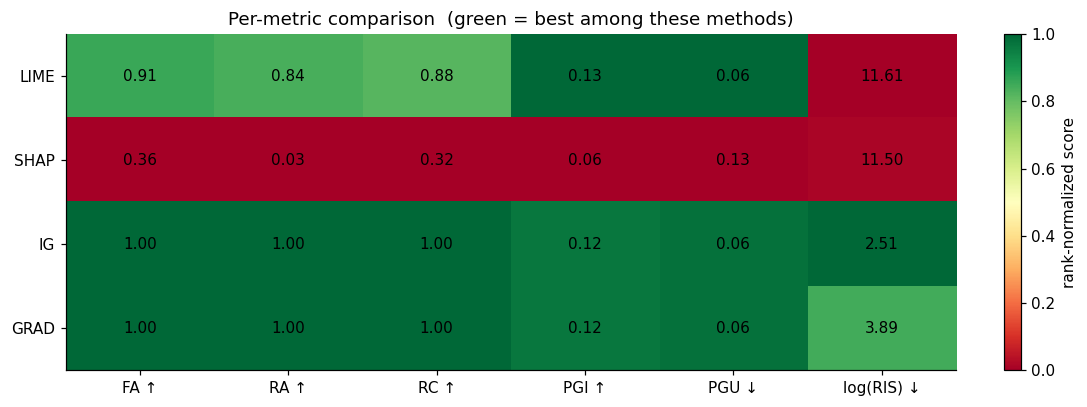

,FA ↑,RA ↑,RC ↑,PGI ↑,PGU ↓,log(RIS) ↓
LIME,0.909444,0.843333,0.875714,0.125594,0.061676,11.610821
SHAP,0.360000,0.025556,0.317363,0.057882,0.127819,11.503724
IG,1.000000,1.000000,1.000000,0.123234,0.063096,2.505802
GRAD,1.000000,1.000000,1.000000,0.123234,0.063096,3.894184


In [ ]:
summary = pd.DataFrame({
    'FA ↑': [gt_results[m]['FA'] for m in explanations],
    'RA ↑': [gt_results[m]['RA'] for m in explanations],
    'RC ↑': [gt_results[m]['RC'] for m in explanations],
    'PGI ↑': [pred_results[m]['PGI'] for m in explanations],
    'PGU ↓': [pred_results[m]['PGU'] for m in explanations],
    'log(RIS) ↓': [np.log(ris_results[m]) for m in explanations],
}, index=[m.upper() for m in explanations])

# Normalize each column to [0, 1] where 1 = best, flipping sign for ↓ metrics
lower_is_better = {'PGU ↓', 'log(RIS) ↓'}
norm = summary.copy()
for col in norm.columns:
    v = norm[col].values.astype(float)
    if col in lower_is_better:
        v = -v
    lo, hi = v.min(), v.max()
    norm[col] = (v - lo) / (hi - lo + 1e-12)

fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(norm.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(norm.columns)))
ax.set_xticklabels(norm.columns)
ax.set_yticks(range(len(norm.index)))
ax.set_yticklabels(norm.index)
for i in range(norm.shape[0]):
    for j in range(norm.shape[1]):
        ax.text(j, i, f'{summary.values[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=10)
ax.set_title('Per-metric comparison  (green = best among these methods)')
fig.colorbar(im, ax=ax, fraction=0.02, label='rank-normalized score')
plt.tight_layout()
plt.show()

summary

## Summary

1. **Explanations disagree.** Even on the *same* model and *same* input, four reasonable methods often highlight different features. Without evaluation, we'd have no way to adjudicate.
2. **Metrics capture different aspects of "goodness".** Faithfulness to ground truth, faithfulness to the model's behavior, and stability are genuinely different properties a method can be great at one and fail another.
3. **Rankings depend on the metric.** Be suspicious of any paper that claims a single explanation method is "best" without specifying under which evaluation criterion.

